In [163]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix

import matplotlib.pyplot as plt

import torch
from torch import nn

from timeit import default_timer as timer

torch.use_deterministic_algorithms(True)

device = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Dispositivo utilizado: {device}")

Dispositivo utilizado: cuda


In [164]:
data = pd.read_excel(
    "earthquake_data_tsunami.xlsx",
    usecols="A:M"
)

data.info()

data.head()

<class 'pandas.DataFrame'>
RangeIndex: 782 entries, 0 to 781
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   magnitude  782 non-null    float64
 1   cdi        782 non-null    int64  
 2   mmi        782 non-null    int64  
 3   sig        782 non-null    int64  
 4   nst        782 non-null    int64  
 5   dmin       782 non-null    float64
 6   gap        782 non-null    float64
 7   depth      782 non-null    float64
 8   latitude   782 non-null    float64
 9   longitude  782 non-null    float64
 10  Year       782 non-null    int64  
 11  Month      782 non-null    int64  
 12  tsunami    782 non-null    int64  
dtypes: float64(6), int64(7)
memory usage: 79.6 KB


,magnitude,cdi,mmi,sig,nst,dmin,gap,depth,latitude,longitude,Year,Month,tsunami
0,7.0,8,7,768,117,0.509,17.0,14.000,-9.7963,159.596,2022,11,1
1,6.9,4,4,735,99,2.229,34.0,25.000,-4.9559,100.738,2022,11,0
2,7.0,3,3,755,147,3.125,18.0,579.000,-20.0508,-178.346,2022,11,1
3,7.3,5,5,833,149,1.865,21.0,37.000,-19.2918,-172.129,2022,11,1
4,6.6,0,2,670,131,4.998,27.0,624.464,-25.5948,178.278,2022,11,1


In [165]:
columns_to_remove = [
    "Year",
    "Month"
]

X = data.drop(
    columns=[
        "tsunami",
        *columns_to_remove
    ]
)

y = data["tsunami"]

In [166]:
# Data splitting:
# 60% training
# 20% validation
# 20% testing

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.4,
    stratify=y,
    random_state=42
)


X_val, X_test, y_val, y_test = train_test_split(
    X_test,
    y_test,
    test_size=0.5,
    random_state=42
)


print("Entrenamiento:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nValidación:")
print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("\nPrueba:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

Entrenamiento:
X_train: (469, 10)
y_train: (469,)

Validación:
X_val: (156, 10)
y_val: (156,)

Prueba:
X_test: (157, 10)
y_test: (157,)


In [167]:
Data_train = pd.concat(
    [
        X_train,
        y_train
    ],
    axis=1
)


# Spearman correlation
# Feature Selection

Spearman_corr = Data_train.corr(
    method="spearman"
)


print(
    Spearman_corr["tsunami"]
    .abs()
    .sort_values(
        ascending=False
    )
)

# Se utilizarán las 10 características restantes
number_of_features = 10


Interesting_features = (
    Spearman_corr["tsunami"]
    .abs()
    .sort_values(
        ascending=False
    )
    .index[
        1:number_of_features + 1
    ]
)


Interesting_features = (
    Interesting_features.tolist()
)


print(
    "\nCaracterísticas seleccionadas:"
)

print(
    Interesting_features
)

tsunami      1.000000
dmin         0.636427
nst          0.627443
cdi          0.249137
mmi          0.122363
latitude     0.119124
gap          0.090446
longitude    0.074218
sig          0.037792
magnitude    0.035611
depth        0.000760
Name: tsunami, dtype: float64

Características seleccionadas:
['dmin', 'nst', 'cdi', 'mmi', 'latitude', 'gap', 'longitude', 'sig', 'magnitude', 'depth']


In [168]:
X_train = X_train[
    Interesting_features
]

X_val = X_val[
    Interesting_features
]

X_test = X_test[
    Interesting_features
]


print("Variables utilizadas:")
print(X_train.columns.tolist())

print("\nForma de entrenamiento:")
print(X_train.shape)

print("\nForma de validación:")
print(X_val.shape)

print("\nForma de prueba:")
print(X_test.shape)

Variables utilizadas:
['dmin', 'nst', 'cdi', 'mmi', 'latitude', 'gap', 'longitude', 'sig', 'magnitude', 'depth']

Forma de entrenamiento:
(469, 10)

Forma de validación:
(156, 10)

Forma de prueba:
(157, 10)


In [169]:
# Normalization

scaler = MinMaxScaler()


X_train_scaled = scaler.fit_transform(
    X_train
)

X_val_scaled = scaler.transform(
    X_val
)

X_test_scaled = scaler.transform(
    X_test
)


print(
    "Valor mínimo de entrenamiento:",
    X_train_scaled.min()
)

print(
    "Valor máximo de entrenamiento:",
    X_train_scaled.max()
)

Valor mínimo de entrenamiento: 0.0
Valor máximo de entrenamiento: 1.0


In [170]:
X_trained_scaled_frame = {}


for i in range(
    len(X_train.columns)
):

    X_trained_scaled_frame[
        X_train.columns[i]
    ] = X_train_scaled[:, i]


X_trained_scaled_frame = pd.DataFrame(
    X_trained_scaled_frame,
    index=X_train.index
)


X_trained_scaled_frame.head()

,dmin,nst,cdi,mmi,latitude,gap,longitude,sig,magnitude,depth
103,0.083994,0.000000,0.777778,0.625,0.766018,0.079498,0.571559,0.012389,0.000000,0.011039
409,0.000000,0.357602,1.000000,0.625,0.406184,0.069038,0.962329,0.057522,0.230769,0.027673
624,0.000000,0.510707,0.000000,0.625,0.447696,0.084937,0.920873,0.000000,0.000000,0.047331
60,0.000000,0.000000,0.888889,0.750,0.934598,0.000000,0.060386,0.266372,0.653846,0.048843
533,0.000000,0.446467,0.777778,0.750,0.473557,0.125941,0.782707,0.060619,0.038462,0.009527


In [171]:
# Balancing

positive_class = np.sum(
    y_train.values == 1
)

negative_class = np.sum(
    y_train.values == 0
)


print(
    f"Positive class: {positive_class}, "
    f"Negative class: {negative_class}"
)

Positive class: 182, Negative class: 287


In [172]:
X_train_balanced = pd.concat(
    [
        X_trained_scaled_frame[
            y_train == 0
        ],

        X_trained_scaled_frame[
            y_train == 1
        ].sample(
            negative_class,
            replace=True,
            random_state=42
        )
    ],
    axis=0
)


y_train_balanced = pd.concat(
    [
        y_train[
            y_train == 0
        ],

        y_train[
            y_train == 1
        ].sample(
            negative_class,
            replace=True,
            random_state=42
        )
    ],
    axis=0
)


print(
    f"Balanced Positive class: "
    f"{np.sum(y_train_balanced.values == 1)}, "
    f"Balanced Negative class: "
    f"{np.sum(y_train_balanced.values == 0)}"
)

Balanced Positive class: 287, Balanced Negative class: 287


In [173]:
X_train_balanced = (
    X_train_balanced.values
)

y_train_balanced = (
    y_train_balanced.values
)

y_val = y_val.values

y_test = y_test.values


print(
    "X_train_balanced:",
    X_train_balanced.shape
)

print(
    "y_train_balanced:",
    y_train_balanced.shape
)

print(
    "X_val_scaled:",
    X_val_scaled.shape
)

print(
    "y_val:",
    y_val.shape
)

print(
    "X_test_scaled:",
    X_test_scaled.shape
)

print(
    "y_test:",
    y_test.shape
)

X_train_balanced: (574, 10)
y_train_balanced: (574,)
X_val_scaled: (156, 10)
y_val: (156,)
X_test_scaled: (157, 10)
y_test: (157,)


In [174]:
class ClassificationModel(nn.Module):

    def __init__(
        self,
        number_of_features,
        hidden_layer_size1,
        hidden_layer_size2,
        hidden_layer_size3,
        number_of_outputs
    ):

        super().__init__()


        self.layer_input = nn.Linear(
            number_of_features,
            hidden_layer_size1
        )
        # w*x+b


        self.hidden_layer_1 = nn.Linear(
            hidden_layer_size1,
            hidden_layer_size2
        )


        self.hidden_layer_2 = nn.Linear(
            hidden_layer_size2,
            hidden_layer_size3
        )


        self.layer_output = nn.Linear(
            hidden_layer_size3,
            number_of_outputs
        )


        self.tanh = nn.Tanh()

        # tanh(x) =
        # (e^x - e^-x) /
        # (e^x + e^-x)


        self.sigmoid = nn.Sigmoid()


    def forward(self, x):

        x = self.tanh(
            self.layer_input(x)
        )

        x = self.tanh(
            self.hidden_layer_1(x)
        )

        x = self.tanh(
            self.hidden_layer_2(x)
        )

        return self.layer_output(x)

In [175]:
def train_step(
    model,
    loss_fn,
    X_train,
    y_train,
    optimizer,
    device=device
):


    X_train = torch.tensor(
        X_train,
        dtype=torch.float32
    ).to(device)


    y_train = torch.tensor(
        y_train,
        dtype=torch.float32
    ).to(device)


    model.train()


    y_logist = model(
        X_train
    ).squeeze()


    y_pred = torch.round(
        torch.sigmoid(
            y_logist
        )
    )


    train_loss = loss_fn(
        y_logist,
        y_train
    )


    train_acc = (
        (y_pred == y_train)
        .sum()
        .item()
        / len(y_pred)
    )


    optimizer.zero_grad()


    train_loss.backward()


    optimizer.step()


    return (
        train_loss.item(),
        train_acc
    )

In [176]:
def val_step(
    model,
    X_val,
    y_val,
    loss_fn,
    optimizer,
    device=device
):


    X_val = torch.tensor(
        X_val,
        dtype=torch.float32
    ).to(device)


    y_val = torch.tensor(
        y_val,
        dtype=torch.float32
    ).to(device)


    model.eval()


    with torch.inference_mode():


        val_logits = model(
            X_val
        ).squeeze()


        val_pred = torch.round(
            torch.sigmoid(
                val_logits
            )
        )


        val_loss = loss_fn(
            val_logits,
            y_val
        )


        val_acc = (
            (val_pred == y_val)
            .sum()
            .item()
            / len(val_pred)
        )


    return (
        val_loss.item(),
        val_acc
    )

In [177]:
def train(
    model,
    X_train,
    y_train,
    X_val,
    y_val,
    optimizer,
    loss_fn,
    epochs,
    device=device
):


    results = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }


    best_val_loss = torch.inf


    MODEL_PATH = "model_trained/"


    for epoch in range(epochs):


        train_loss, train_acc = train_step(
            model=model,
            X_train=X_train,
            y_train=y_train,
            loss_fn=loss_fn,
            optimizer=optimizer,
            device=device
        )


        val_loss, val_acc = val_step(
            model=model,
            X_val=X_val,
            y_val=y_val,
            loss_fn=loss_fn,
            optimizer=optimizer,
            device=device
        )


        if val_loss < best_val_loss:


            best_val_loss = val_loss


            MODEL_NAME = (
                "classifier_tsunami.pth"
            )


            MODEL_SAVE_PATH = (
                MODEL_PATH
                + MODEL_NAME
            )


            torch.save(
                model.state_dict(),
                MODEL_SAVE_PATH
            )


        print(
            f"Epoch: {epoch} | "
            f"Train loss: "
            f"{train_loss:.4f} "
            f"Train acc: "
            f"{train_acc:.4f} | "
            f"Val loss: "
            f"{val_loss:.4f} "
            f"Val acc: "
            f"{val_acc:.4f}"
        )


        results[
            "train_loss"
        ].append(
            train_loss
        )


        results[
            "train_acc"
        ].append(
            train_acc
        )


        results[
            "val_loss"
        ].append(
            val_loss
        )


        results[
            "val_acc"
        ].append(
            val_acc
        )


    return results

In [178]:
torch.manual_seed(42)

torch.cuda.manual_seed(42)


NUM_EPOCHS = 2000


HIDDEN_LAYER_SIZE1 = 10

HIDDEN_LAYER_SIZE2 = 6

HIDDEN_LAYER_SIZE3 = 2


model = ClassificationModel(
    number_of_features=number_of_features,
    hidden_layer_size1=HIDDEN_LAYER_SIZE1,
    hidden_layer_size2=HIDDEN_LAYER_SIZE2,
    hidden_layer_size3=HIDDEN_LAYER_SIZE3,
    number_of_outputs=1
).to(device)


loss_fn = nn.BCEWithLogitsLoss()


optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.01
)


print(model)

ClassificationModel(
  (layer_input): Linear(in_features=10, out_features=10, bias=True)
  (hidden_layer_1): Linear(in_features=10, out_features=6, bias=True)
  (hidden_layer_2): Linear(in_features=6, out_features=2, bias=True)
  (layer_output): Linear(in_features=2, out_features=1, bias=True)
  (tanh): Tanh()
  (sigmoid): Sigmoid()
)


In [179]:
start_time = timer()


model_results = train(
    model=model,
    X_train=X_train_balanced,
    y_train=y_train_balanced,
    X_val=X_val_scaled,
    y_val=y_val,
    device=device,
    optimizer=optimizer,
    loss_fn=loss_fn,
    epochs=NUM_EPOCHS
)


end_time = timer()


print(
    f"Total training time "
    f"{end_time - start_time:.3f} "
    f"seconds"
)

Epoch: 0 | Train loss: 0.7165 Train acc: 0.5000 | Val loss: 0.7619 Val acc: 0.3782
Epoch: 1 | Train loss: 0.7132 Train acc: 0.5000 | Val loss: 0.7553 Val acc: 0.3782
Epoch: 2 | Train loss: 0.7100 Train acc: 0.5000 | Val loss: 0.7487 Val acc: 0.3782
Epoch: 3 | Train loss: 0.7068 Train acc: 0.5000 | Val loss: 0.7422 Val acc: 0.3782
Epoch: 4 | Train loss: 0.7037 Train acc: 0.5000 | Val loss: 0.7356 Val acc: 0.3782


Epoch: 5 | Train loss: 0.7008 Train acc: 0.5000 | Val loss: 0.7290 Val acc: 0.3782
Epoch: 6 | Train loss: 0.6980 Train acc: 0.5000 | Val loss: 0.7225 Val acc: 0.3782
Epoch: 7 | Train loss: 0.6954 Train acc: 0.5000 | Val loss: 0.7161 Val acc: 0.3782
Epoch: 8 | Train loss: 0.6931 Train acc: 0.5000 | Val loss: 0.7098 Val acc: 0.3782
Epoch: 9 | Train loss: 0.6909 Train acc: 0.5000 | Val loss: 0.7038 Val acc: 0.3782
Epoch: 10 | Train loss: 0.6890 Train acc: 0.5000 | Val loss: 0.6982 Val acc: 0.3782
Epoch: 11 | Train loss: 0.6873 Train acc: 0.5000 | Val loss: 0.6930 Val acc: 0.3782
Epoch: 12 | Train loss: 0.6856 Train acc: 0.5209 | Val loss: 0.6883 Val acc: 0.6987
Epoch: 13 | Train loss: 0.6840 Train acc: 0.7892 | Val loss: 0.6840 Val acc: 0.7372
Epoch: 14 | Train loss: 0.6820 Train acc: 0.7613 | Val loss: 0.6802 Val acc: 0.6795
Epoch: 15 | Train loss: 0.6796 Train acc: 0.6847 | Val loss: 0.6767 Val acc: 0.6731
Epoch: 16 | Train loss: 0.6764 Train acc: 0.6568 | Val loss: 0.6735 Val acc: 0.69

In [180]:
def plot_loss_curves(results):


    train_loss = results[
        "train_loss"
    ]

    test_loss = results[
        "val_loss"
    ]


    train_acc = results[
        "train_acc"
    ]

    test_acc = results[
        "val_acc"
    ]


    epochs = range(
        len(train_loss)
    )


    plt.figure(
        figsize=(15, 7)
    )


    plt.subplot(
        1,
        2,
        1
    )


    plt.plot(
        epochs,
        train_loss,
        label="train_loss"
    )


    plt.plot(
        epochs,
        test_loss,
        label="val_loss"
    )


    plt.title(
        "Loss"
    )

    plt.xlabel(
        "Epochs"
    )

    plt.legend()


    plt.subplot(
        1,
        2,
        2
    )


    plt.plot(
        epochs,
        train_acc,
        label="train_acc"
    )


    plt.plot(
        epochs,
        test_acc,
        label="val_acc"
    )


    plt.title(
        "Accuracy"
    )

    plt.xlabel(
        "Epochs"
    )

    plt.legend()


    plt.show()

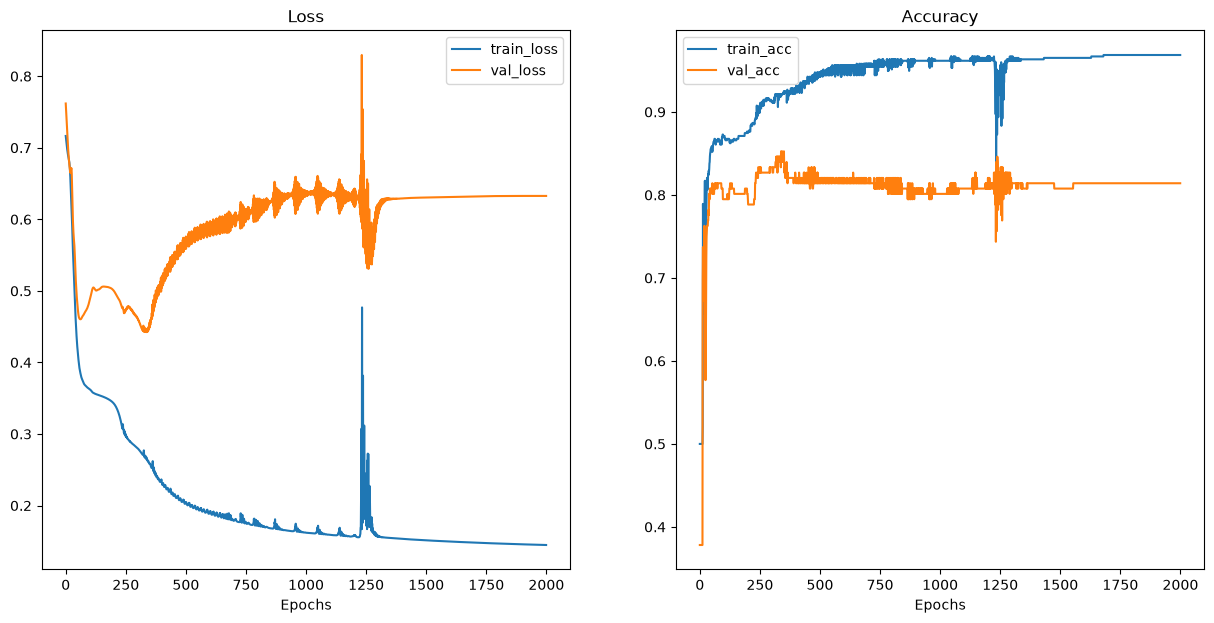

In [181]:
plot_loss_curves(
    model_results
)

In [182]:
model = ClassificationModel(
    number_of_features=number_of_features,
    hidden_layer_size1=HIDDEN_LAYER_SIZE1,
    hidden_layer_size2=HIDDEN_LAYER_SIZE2,
    hidden_layer_size3=HIDDEN_LAYER_SIZE3,
    number_of_outputs=1
).to(device)


MODEL_PATH = "model_trained/"

MODEL_NAME = (
    "classifier_tsunami.pth"
)


MODEL_SAVE_PATH = (
    MODEL_PATH
    + MODEL_NAME
)


model.load_state_dict(
    torch.load(
        MODEL_SAVE_PATH,
        map_location=device
    )
)


print(
    "Modelo cargado correctamente"
)

Modelo cargado correctamente


In [183]:
from sklearn.metrics import accuracy_score

model.eval()

with torch.inference_mode():

    y_val_logits = model(
        torch.tensor(
            X_val_scaled,
            dtype=torch.float32
        ).to(device)
    ).squeeze()

    y_val_probability = torch.sigmoid(
        y_val_logits
    ).cpu().numpy()


thresholds = np.arange(
    0.30,
    0.71,
    0.01
)

best_threshold = 0.5
best_val_accuracy = 0


for threshold in thresholds:

    y_val_pred_threshold = (
        y_val_probability >= threshold
    ).astype(int)

    current_accuracy = accuracy_score(
        y_val,
        y_val_pred_threshold
    )

    if current_accuracy > best_val_accuracy:

        best_val_accuracy = current_accuracy
        best_threshold = threshold


print(
    f"Mejor umbral: {best_threshold:.2f}"
)

print(
    f"Accuracy de validación: "
    f"{best_val_accuracy * 100:.2f}%"
)

Mejor umbral: 0.55
Accuracy de validación: 85.26%


In [184]:
model.eval()


with torch.inference_mode():


    y_test_logits = model(
        torch.tensor(
            X_test_scaled,
            dtype=torch.float32
        ).to(device)
    ).squeeze()


    y_test_probability = (
        torch.sigmoid(
            y_test_logits
        )
    )


    y_test_pred = (
        y_test_probability >= best_threshold
    ).float()


    y_test_pred = (
        y_test_pred
        .cpu()
        .numpy()
    )


y_test_pred

array([0., 0., 1., 0., 1., 0., 0., 1., 1., 0., 0., 0., 1., 0., 0., 1., 0.,
       1., 0., 0., 1., 0., 0., 0., 0., 0., 1., 1., 1., 0., 1., 0., 1., 0.,
       0., 0., 0., 0., 1., 0., 0., 1., 0., 1., 0., 0., 1., 1., 0., 1., 0.,
       0., 1., 0., 0., 1., 0., 0., 0., 1., 1., 1., 1., 0., 0., 0., 0., 1.,
       1., 0., 0., 1., 0., 1., 1., 0., 1., 1., 1., 1., 0., 1., 0., 0., 0.,
       0., 0., 0., 1., 1., 1., 0., 0., 0., 1., 0., 1., 1., 1., 0., 1., 1.,
       1., 0., 0., 0., 0., 1., 0., 1., 1., 0., 1., 1., 1., 0., 0., 1., 0.,
       1., 0., 0., 1., 0., 0., 1., 1., 0., 0., 1., 1., 0., 1., 1., 0., 0.,
       1., 0., 1., 0., 0., 0., 1., 0., 0., 0., 0., 1., 1., 0., 0., 0., 1.,
       0., 0., 0., 0.], dtype=float32)

In [185]:
print(
    classification_report(
        y_test,
        y_test_pred,
        target_names=[
            "Sin tsunami",
            "Con tsunami"
        ]
    )
)

              precision    recall  f1-score   support

 Sin tsunami       0.90      0.87      0.89        94
 Con tsunami       0.82      0.86      0.84        63

    accuracy                           0.87       157
   macro avg       0.86      0.86      0.86       157
weighted avg       0.87      0.87      0.87       157



In [186]:
matrix = confusion_matrix(
    y_test,
    y_test_pred
)


print(
    "Matriz de confusión:"
)

print(matrix)

Matriz de confusión:
[[82 12]
 [ 9 54]]


In [187]:
results_dataframe = pd.DataFrame(
    {
        "Valor real": y_test,
        "Predicción": y_test_pred
    }
)


results_dataframe.head(20)

,Valor real,Predicción
0,0,0.0
1,0,0.0
2,1,1.0
3,0,0.0
4,1,1.0
5,0,0.0
6,0,0.0
7,1,1.0
8,0,1.0
9,0,0.0


In [188]:
correct_predictions = np.sum(
    y_test == y_test_pred
)


total_predictions = len(
    y_test
)


accuracy_percentage = (
    correct_predictions
    / total_predictions
) * 100


print(
    f"Predicciones correctas: "
    f"{correct_predictions}"
)

print(
    f"Total de predicciones: "
    f"{total_predictions}"
)

print(
    f"Porcentaje de efectividad: "
    f"{accuracy_percentage:.2f}%"
)

Predicciones correctas: 136
Total de predicciones: 157
Porcentaje de efectividad: 86.62%
